In [32]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
RESULTS_DIR = Path("../../data/results/similarity_qed_pubchem")

In [34]:
# Define experiment groups: (model, folder_name)
GROUPS = [
    ("claude-sonnet-4.5", "claude-sonnet-4.5_full_xai"),
    ("claude-opus-4.5", "claude-opus-4.5_full_xai"),
    ("gpt-5.1", "gpt-5.1_full_xai"),
    ("gpt-4.1", "gpt-4.1_full_xai"),
    ("gpt-5.1_reasoning", "gpt-5.1_full_xai_medium"),
]

def load_trace(p):
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d

# Load all data into a single DataFrame
rows = []
for model, folder in GROUPS:
    files = sorted((RESULTS_DIR / folder).glob("sim_qed_pubchem_*.json"))
    if not files:
        raise FileNotFoundError(f"No files in {RESULTS_DIR/folder} matching sim_qed_pubchem_*.json")
    
    for file_idx, file_path in enumerate(files):
        # Extract target molecule (e.g., "mol1", "mol2") from filename
        mol_match = re.search(r'mol\d+', file_path.name)
        target_molecule = mol_match.group() if mol_match else f"mol{file_idx}"
        
        trace = load_trace(file_path)
        for entry in trace:
            rows.append({
                "model": model,
                "target_molecule": target_molecule,
                "iteration": int(entry["iteration"]),
                "score": float(entry["score"]),
                "smiles": entry["smiles"],
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} models")
df.head(10)


Loaded 4062 rows from 5 models


,model,target_molecule,iteration,score,smiles
0,claude-sonnet-4.5,mol10,1,0.639876,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1
1,claude-sonnet-4.5,mol10,2,0.774726,Cc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C)cc1
2,claude-sonnet-4.5,mol10,3,0.171036,CCCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)c2...
3,claude-sonnet-4.5,mol10,4,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
4,claude-sonnet-4.5,mol10,5,0.735445,CCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C2C...
5,claude-sonnet-4.5,mol10,6,0.772393,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)C)cc1
6,claude-sonnet-4.5,mol10,7,0.171036,CCCc1nn(-c2ccccc2C)c(OC(C)=O)c1-c1ccc(NC(=O)c2...
7,claude-sonnet-4.5,mol10,8,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
8,claude-sonnet-4.5,mol10,9,0.794607,CCc1nn(C)c(OC(=O)C)c1-c1ccc(NC(=O)c2cccs2)cc1
9,claude-sonnet-4.5,mol10,10,0.769309,CCc1nn(C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1


In [39]:
# Check for runs with fewer than 51 iterations (excluding gpt-5.1_reasoning)
df_filtered = df[df['model'] != 'gpt-5.1_reasoning']
run_lengths = df_filtered.groupby(['model', 'target_molecule'])['iteration'].max()
short_runs = run_lengths[run_lengths < 51]

if len(short_runs) > 0:
    print(f"\nFound {len(short_runs)} runs with fewer than 51 iterations:")
    print(short_runs.sort_values())
else:
    print("\nAll runs have 51 iterations")


Found 80 runs with fewer than 51 iterations:
model              target_molecule
claude-opus-4.5    mol20              35
gpt-5.1            mol9               48
claude-opus-4.5    mol6               49
gpt-4.1            mol6               49
                   mol7               50
                                      ..
claude-sonnet-4.5  mol14              50
                   mol13              50
                   mol12              50
                   mol19              50
                   mol9               50
Name: iteration, Length: 80, dtype: int64


In [35]:
import yaml

REINVENT_DIR = Path("../../data/results/reinvent/random_molecules_sim_qed")

def load_reinvent_results(reinvent_dir: Path) -> pd.DataFrame:
    """Load Reinvent baseline results from YAML files.
    
    Each YAML file has SMILES as keys and [score, step_number] as values.
    We need to reconstruct iteration-wise best scores from the step numbers.
    """
    rows = []
    
    for mol_dir in sorted(reinvent_dir.glob("mol_*")):
        yaml_files = list(mol_dir.glob("results_reinvent_*.yaml"))
        if not yaml_files:
            continue
            
        yaml_file = yaml_files[0]
        target_molecule = mol_dir.name.replace("_", "")  # "mol_1" -> "mol1"
        
        with open(yaml_file, 'r') as f:
            data = yaml.safe_load(f)
        
        # Parse the YAML: keys are SMILES, values are [score, step_number]
        mol_results = []
        for smiles, values in data.items():
            score = values[0]
            step = values[1]
            mol_results.append({
                "smiles": smiles,
                "score": score,
                "step": step,
                "target_molecule": target_molecule,
            })
        
        # Sort by step number and compute iteration (1-indexed)
        mol_df = pd.DataFrame(mol_results).sort_values("step")
        mol_df["iteration"] = range(1, len(mol_df) + 1)
        
        for _, row in mol_df.iterrows():
            rows.append({
                "model": "Reinvent",
                "xai_mode": "baseline",
                "target_molecule": row["target_molecule"],
                "iteration": row["iteration"],
                "score": row["score"],
                "smiles": row["smiles"],
            })
    
    return pd.DataFrame(rows)

# Load Reinvent data
df_reinvent = load_reinvent_results(REINVENT_DIR)
print(f"Loaded {len(df_reinvent)} rows from Reinvent baseline")
print(f"Target molecules: {df_reinvent['target_molecule'].nunique()}")
print(f"Iterations per molecule: {df_reinvent.groupby('target_molecule')['iteration'].max().describe()}")
df_reinvent.head(10)

Loaded 20020 rows from Reinvent baseline
Target molecules: 20
Iterations per molecule: count      20.0
mean     1001.0
std         0.0
min      1001.0
25%      1001.0
50%      1001.0
75%      1001.0
max      1001.0
Name: iteration, dtype: float64


,model,xai_mode,target_molecule,iteration,score,smiles
0,Reinvent,baseline,mol1,1,0.198832,Cn1cc(C(C)(C)C)cc1/C=C(\C#N)C(=O)c1ccc([N+](=O...
1,Reinvent,baseline,mol1,2,0.499546,NC(=O)c1ccc(CSCc2ccccc2)nc1
2,Reinvent,baseline,mol1,3,0.404276,CN(Cc1ccccc1O)C(=O)N[C@@H](Cc1ccccc1)c1ccccn1
3,Reinvent,baseline,mol1,4,0.389506,COC(=O)[C@@H](C)Sc1nc2ccc(Cl)cc2n1CC(=O)[O-]
4,Reinvent,baseline,mol1,5,0.497607,O=C(/C=C/SCc1cccnc1)Nc1cc(C(F)(F)F)ccc1Cl
5,Reinvent,baseline,mol1,6,0.504678,Cc1ocnc1CNC(=O)N1CCCCC[C@@H]1c1cccn1C
6,Reinvent,baseline,mol1,7,0.341852,O=C(NCc1ccccn1)c1ccccc1NC(=S)NCc1ccco1
7,Reinvent,baseline,mol1,8,0.388157,CC[NH+]1CCN(c2ncnc(N)c2O)[C@H](C(C)C)C1
8,Reinvent,baseline,mol1,9,0.448412,Cc1cccc(C2=NN=C[C@H]2COC(=O)c2ccco2)c1
9,Reinvent,baseline,mol1,10,0.477724,CCCCN1C(=O)Cc2ccc(NC(=O)C(=O)N3CCCCCC3)cc21


Text(0.5, 1.0, 'Best-so-far progression (LLMs + Reinvent)')

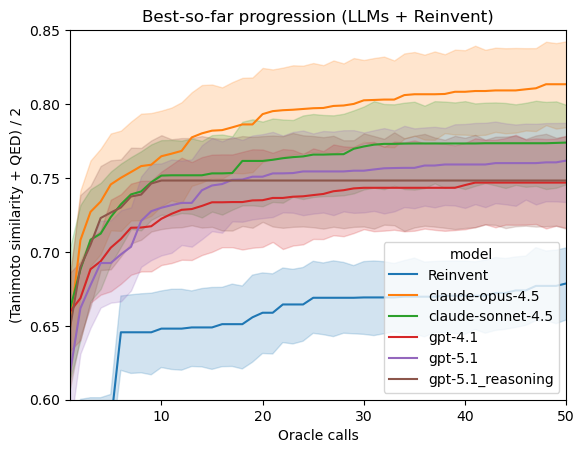

In [36]:
# Combine LLM and Reinvent data
df_combined = pd.concat([df, df_reinvent], ignore_index=True)

# Compute best-so-far (cummax needs data sorted by iteration)
df_combined["best_so_far"] = (
    df_combined.sort_values("iteration")
    .groupby(["model", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df_combined[df_combined["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(data=df_plot, x="iteration", y="value", hue="model", errorbar=('ci', 95))
plt.xlabel("Oracle calls")
plt.ylabel("(Tanimoto similarity + QED) / 2")
plt.xlim(1, 50)
plt.ylim(0.6,0.85)
plt.title("Best-so-far progression (LLMs + Reinvent)")

In [37]:
# Find first iteration where best_so_far >= 0.7 threshold for each (model, target_molecule)
from scipy import stats

THRESHOLD = 0.7

def first_iteration_above_threshold(group, threshold=THRESHOLD):
    """Return first iteration where best_so_far >= threshold, or NaN if never reached."""
    above = group[group["best_so_far"] >= threshold]
    if len(above) > 0:
        return above["iteration"].min()
    return np.nan

def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) == 0:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high

# Compute for each model and target molecule
iter_to_threshold = (
    df_combined
    .groupby(["model", "target_molecule"])
    .apply(first_iteration_above_threshold, include_groups=False)
    .reset_index(name="iter_to_0.7")
)

# Summarize by model with bootstrap CI
summary_rows = []
for model, group in iter_to_threshold.groupby("model"):
    values = group["iter_to_0.7"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows.append({
        "model": model,
        "Mean Iteration": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate": success_rate
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("model").round(2)

print("Iteration to reach 0.7 threshold (best-so-far) with 95% Bootstrap CI")
threshold_summary

Iteration to reach 0.7 threshold (best-so-far) with 95% Bootstrap CI


,Mean Iteration,CI 95% Low,CI 95% High,N,Never Reached,Success Rate
model,,,,,,
Reinvent,138.21,59.86,287.74,20,6,70.0
claude-opus-4.5,7.42,3.84,13.21,20,1,95.0
claude-sonnet-4.5,3.59,2.00,7.82,20,3,85.0
gpt-4.1,4.43,2.43,8.86,20,6,70.0
gpt-5.1,7.59,4.35,13.78,20,3,85.0
gpt-5.1_reasoning,2.31,1.69,3.68,20,4,80.0
